In [ ]:
%pip install pyterrier
%pip install pyterrier[java]

In [ ]:
import pyterrier as pt
import pickle
import pandas as pd
import shutil
import os
import re
from pathlib import Path
from pyterrier.measures import *

# Data exploration

In [663]:
dataset = pt.get_dataset('irds:beir/fiqa/test')

In [664]:
dataset.get_corpus_iter()

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

In [665]:
queries = dataset.get_topics()
display(queries)

,qid,query
0,4641,Where should I park my rainy-day / emergency f...
1,5503,Tax considerations for selling a property belo...
2,7803,Can the Delta be used to calculate the option ...
3,7017,Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small ...
...,...,...
643,4102,How can I determine if my rate of return is “g...
644,3566,Where can I buy stocks if I only want to inves...
645,94,Using credit card points to pay for tax deduct...
646,2551,How to find cheaper alternatives to a traditio...


In [666]:
qrels = dataset.get_qrels()
display(qrels)

,qid,docno,label,iteration
0,8,566392,1,0
1,8,65404,1,0
2,15,325273,1,0
3,18,88124,1,0
4,26,285255,1,0
...,...,...,...,...
1701,11039,330058,1,0
1702,11039,91183,1,0
1703,11054,155053,1,0
1704,11054,321015,1,0


Overall Statistics
count    648.000000
mean       2.632716
std        2.062616
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       15.000000
Name: docno, dtype: float64


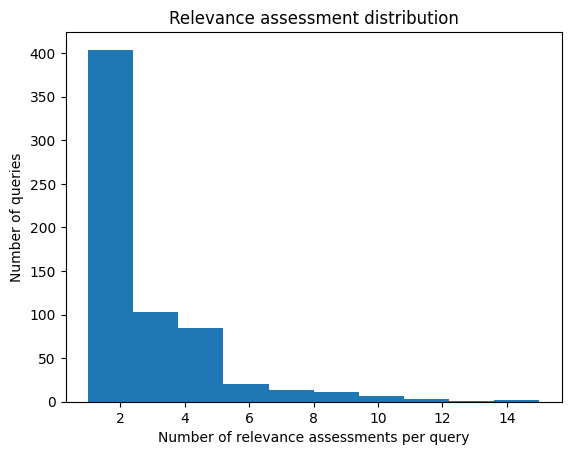

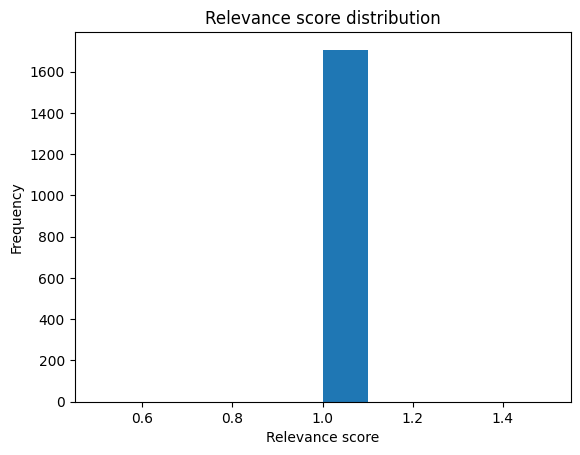

In [667]:
%pip install matplotlib
import matplotlib.pyplot as plt
counts = qrels.groupby("qid")["docno"].count()
print("Overall Statistics")
print(counts.describe())

plt.figure()
counts.plot(kind="hist")
plt.xlabel("Number of relevance assessments per query")
plt.ylabel("Number of queries")
plt.title("Relevance assessment distribution")
plt.show()

counts.sort_values(ascending=False).head()

qrels["label"].value_counts()

plt.figure()
qrels["label"].plot(kind="hist")
plt.xlabel("Relevance score")
plt.ylabel("Frequency")
plt.title("Relevance score distribution")
plt.show()

In [668]:
def ensure_java_home():
    if os.environ.get("JAVA_HOME"):
        return
    java = shutil.which("java.exe" if os.name == "nt" else "java")
    if java:
        jdk_parent = Path(java).resolve().parents[1]
        cand = jdk_parent / ("bin/java.exe" if os.name == "nt" else "bin/java")
        if cand.exists():
            os.environ["JAVA_HOME"] = str(jdk_parent)
            return
    if not os.environ.get("JAVA_HOME"):
        raise EnvironmentError(
            "JAVA_HOME is not set. Install a JDK and set JAVA_HOME to the JDK folder."
        )

ensure_java_home()

def indexing(index_path, ds):
    index_path = str(Path(f"./{index_path}").resolve())
    if os.path.exists(index_path):
        shutil.rmtree(index_path)
    indexer = pt.index.IterDictIndexer(index_path, meta={'docno':35})
    indexref = indexer.index(ds.get_corpus_iter())
    index = pt.IndexFactory.of(indexref)
    stats = index.getCollectionStatistics()
    return indexref, stats

def rmv_problems(text: str) -> str:
    text = str(text)
    text = text.replace(":", " ")
    text = text.replace("'", " ")
    text = text.replace('"', " ")
    text = re.sub(r"\s+", " ", text).strip()

    return text



In [669]:
indexref, stats = indexing('beir-index', dataset)

beir/fiqa/test documents:   0%|          | 0/57638 [00:00<?, ?it/s]

21:40:29.120 [ForkJoinPool-31-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
21:40:40.034 [ForkJoinPool-31-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents


In [670]:
print("Index folder:", 'beir-index')
print("Number of documents:", stats.getNumberOfDocuments())
print("Number of postings:", stats.getNumberOfPostings())
print("Number of tokens:", stats.getNumberOfTokens())
print("Number of unique terms:", stats.getNumberOfUniqueTerms())
print(f"Average document length:{stats.getAverageDocumentLength():.2f}")


Index folder: beir-index
Number of documents: 57638
Number of postings: 2714611
Number of tokens: 3783214
Number of unique terms: 51260
Average document length:65.64


# Baseline models

In [671]:
bm25 = pt.terrier.Retriever(indexref, wmodel='BM25')
tfidf = pt.terrier.Retriever(indexref, wmodel="TF_IDF")

In [672]:
queries['query'] = queries['query'].apply(rmv_problems)

In [673]:
res_bm25 = bm25.transform(queries[['qid','query']])
res_tfidf = tfidf.transform(queries[['qid','query']])

In [674]:
metrics = [P@1, P@5, P@10, R@5, R@10, nDCG@5, nDCG@10, AP]

1st baseline experiment

In [675]:
base1 = pt.Experiment(
    [tfidf, bm25],
    queries,
    qrels,
    eval_metrics=metrics,
    names=["TF_IDF", "BM25"],
    #baseline=0,
    verbose=True,
)
base1

pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,TF_IDF,0.209962,0.236111,0.108642,0.071142,0.249805,0.313278,0.231547,0.253659
1,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589


2nd baseline experiment: custom formulas + RRF

In [ ]:
%pip install pyterrier_alpha

In [476]:
import pyterrier_alpha as pta
combined = bm25 + tfidf
dph = pt.terrier.Retriever(indexref, wmodel="DPH")

rrf = pta.RRFusion(bm25, tfidf, k=60, num_results=1000)
weighted_linear = bm25 + 2 * dph

Largely stagnant performance

In [477]:
systems = [bm25, tfidf, combined, weighted_linear, rrf]
names   = ["BM25", "TF_IDF", "(BM25+TFIDF)", "Weighted(BM25+2*TFIDF)", "RRF"]

base2 = pt.Experiment(
    systems,
    queries,
    qrels,
    metrics,
    names,
    perquery=False
)
display(base2)

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,BM25,0.210385,0.236111,0.106481,0.070370,0.247471,0.309708,0.230060,0.252589
1,TF_IDF,0.209962,0.236111,0.108642,0.071142,0.249805,0.313278,0.231547,0.253659
2,(BM25+TFIDF),0.210414,0.236111,0.108025,0.070216,0.249713,0.308250,0.231324,0.252182
3,Weighted(BM25+2*TFIDF),0.208011,0.239198,0.107099,0.070216,0.242903,0.311580,0.228979,0.252283
4,RRF,0.209778,0.236111,0.108025,0.069907,0.248620,0.307249,0.230670,0.251379


3rd baseline experiment

In [ ]:
%pip install transformers

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

model_id = "microsoft/Phi-3.5-mini-instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype="auto"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

In [ ]:
def parse_terms(out: str, n_terms=10):
    out = out.strip().replace('"','').replace("'","")
    terms = [t.strip() for t in re.split(r"[,\n;]+", out) if t.strip()]
    terms = [t for t in terms if 1 <= len(t.split()) <= 4][:n_terms]
    return terms

def expand_queries_in_batches(queries_df, tokenizer, pipe, batch_size=16, n_terms=10):
    prompts = []
    for q in queries_df["query"].tolist():
        prompts.append(
            f"""Return ONLY a comma-separated list of 12 short finance keywords/phrases (1-3 words).
No new companies, tickers, dates, numbers, currencies. No explanations.
Query: {q}
Expansion:"""
        )

    expanded = []
    for i in range(0, len(prompts), batch_size):
        batch_prompts = prompts[i:i+batch_size]
        outs = pipe(
            batch_prompts,
            max_new_tokens=60,
            do_sample=False,
            temperature=0.0,
            return_full_text=False
        )
        for q, o in zip(queries_df["query"].iloc[i:i+batch_size], outs):
            gen_text = o[0]["generated_text"]
            terms = parse_terms(gen_text, n_terms=n_terms)
            expanded.append(q + " " + " ".join(terms))

    out_df = queries_df.copy()
    out_df["query"] = expanded
    return out_df


In [ ]:
queries_exp = expand_queries_in_batches(queries, tokenizer, pipe, batch_size=16)

In [ ]:
queries_exp = pd.read_csv('./data/expanded_llm.csv')

In [ ]:
queries = queries[["qid","query"]].copy()
queries_exp = queries_exp[["qid","query"]].copy()

qid2exp = dict(zip(queries_exp["qid"], queries_exp["query"]))

# transformer: replace query text based on qid
rewrite_from_precomputed = pt.apply.generic(
    lambda df: df.assign(
        query=df["qid"].map(qid2exp).where(
            df["qid"].map(qid2exp).notna(),
            df["query"]
        ).astype(str)
    )
)
bm25_exp = rewrite_from_precomputed >> bm25

results = pt.Experiment(
    [bm25, bm25_exp],
    queries,          
    qrels,
    eval_metrics=metrics,
    names=["BM25", "BM25 + LLM expansion"],
    verbose=True
)
results

# Advanced models

## MonoT5/DuoT5 reranking

In [676]:
!pip install --upgrade git+https://github.com/terrierteam/pyterrier_t5.git

from pyterrier_t5 import MonoT5ReRanker, DuoT5ReRanker
monoT5 = MonoT5ReRanker()
duoT5 = DuoT5ReRanker()
bm25 = pt.BatchRetrieve(indexref, wmodel="BM25")
mono_pipeline = bm25 %100 >> pt.text.get_text(dataset, "text") >> monoT5
duo_pipeline = mono_pipeline % 5 >> duoT5

  Cloning https://github.com/terrierteam/pyterrier_t5.git to /tmp/pip-req-build-_2rglivh
  Running command git clone --filter=blob:none --quiet https://github.com/terrierteam/pyterrier_t5.git /tmp/pip-req-build-_2rglivh
  Resolved https://github.com/terrierteam/pyterrier_t5.git to commit 81f4c49c6541e6ceedffd2e705cf2fe20089c3ae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


/tmp/ipython-input-4089261668.py:6: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  bm25 = pt.BatchRetrieve(indexref, wmodel="BM25")


In [677]:
results_T5 = pt.Experiment(
    [mono_pipeline, duo_pipeline],
    queries,
    qrels,
    metrics,
    ["monoT5", "duoT5"],
    verbose = True
)

results_T5

pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

monoT5:   0%|          | 0/16193 [00:00<?, ?batches/s]

monoT5:   0%|          | 0/16193 [00:00<?, ?batches/s]

duoT5:   0%|          | 0/648 [00:00<?, ?queries/s]

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,monoT5,0.324764,0.390432,0.17037,0.102932,0.379485,0.447590,0.367942,0.387979
1,duoT5,0.272094,0.330247,0.17037,0.085185,0.379485,0.379485,0.345132,0.337003


## Tagging idea

### Sentiment Analysis

In [480]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

pipe = pipeline("text-classification", model="ProsusAI/finbert")

tokenizer_finbert = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model_finbert = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

Device set to use cuda:0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_finbert.to(device).eval()

LABELS = ["negative", "neutral", "positive"]

def iter_batches(corpus_iter, batch_size=32):
    batch = []
    for item in corpus_iter:
        # expects dict with keys: 'docno', 'text'
        batch.append(item)
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch

rows = []
batch_size = 32  # increase (e.g., 64/128) if you have GPU memory

for batch in iter_batches(dataset.get_corpus_iter(), batch_size=batch_size):
    docnos = [d["docno"] for d in batch]
    texts  = [d["text"]  for d in batch]

    inputs = tokenizer_finbert(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        logits = model_finbert(**inputs).logits

    probs = torch.softmax(logits, dim=-1)                 # (B, 3)
    pred_ids = probs.argmax(dim=-1).tolist()              # list length B
    confs = probs.max(dim=-1).values.tolist()             # confidence of chosen class

    for docno, pred_id, conf in zip(docnos, pred_ids, confs):
        rows.append({
            "docno": docno,
            "sentiment": LABELS[pred_id],
            "confidence": conf
        })

sentiment_df = pd.DataFrame(rows)
sentiment_df


In [ ]:
sentiment_df.to_csv('sentiment_df.csv')

In [ ]:
rows_q = []
for batch in iter_batches(queries.to_dict(orient='records'), batch_size=batch_size):
    qids = [d["qid"] for d in batch]
    qs  = [d["query"]  for d in batch]

    inputs = tokenizer_finbert(
        qs,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        logits = model_finbert(**inputs).logits

    probs = torch.softmax(logits, dim=-1)                 # (B, 3)
    pred_ids = probs.argmax(dim=-1).tolist()              # list length B
    confs = probs.max(dim=-1).values.tolist()             # confidence of chosen class

    for qid, pred_id, conf in zip(qids, pred_ids, confs):
        rows_q.append({
            "qid": qid,
            "sentiment": LABELS[pred_id],
            "confidence": conf
        })

sentiment_q = pd.DataFrame(rows_q)
sentiment_q


In [ ]:
sentiment_q.to_csv('sentiment_q.csv')

### Named Entity Recognition

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import pipeline

tokenizerNER = AutoTokenizer.from_pretrained("dslim/bert-base-NER")
modelNER = AutoModelForTokenClassification.from_pretrained("dslim/bert-base-NER")

nlp = pipeline("ner", model=modelNER, tokenizer=tokenizerNER)
example = "My name is Wolfgang and I live in Berlin"

ner_results = nlp(example)
print(ner_results)

In [ ]:
# aggregation_strategy merges wordpieces and groups spans nicely
nlp = pipeline(
    "ner",
    model=modelNER,
    tokenizer=tokenizerNER,
    aggregation_strategy="simple"   # key improvement vs raw token outputs
)

rows_ner = []
batch_size_ner = 16  # increase if you have GPU / enough RAM

for batch in iter_batches(dataset.get_corpus_iter(), batch_size=batch_size_ner):
    docnos = [d["docno"] for d in batch]
    texts  = [d["text"] for d in batch]

    # pipeline supports list input => batched inference
    outputs = nlp(texts)

    # outputs is a list (per doc) of entity dicts
    for docno, ents in zip(docnos, outputs):
        words = [e.get("word", "") for e in ents if e.get("word")]
        rows_ner.append({"docno": docno, "entities": words})

df_ner = pd.DataFrame(rows_ner)
df_ner


In [ ]:
df_ner.to_csv("df_ner.csv")

In [ ]:
rows_ner_q = []
for batch in iter_batches(queries.to_dict(orient='records'), batch_size=batch_size_ner):
    qids = [d["qid"] for d in batch]
    qs  = [d["query"]  for d in batch]

    # pipeline supports list input => batched inference
    outputs = nlp(texts)

    # outputs is a list (per doc) of entity dicts
    for qid, ents in zip(qids, outputs):
        words = [e.get("word", "") for e in ents if e.get("word")]
        rows_ner_q.append({"qid": qid, "entities": words})

df_ner_q = pd.DataFrame(rows_ner_q)
df_ner_q

In [ ]:
tags_classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

In [ ]:
sequence_test = "one day I will see the world"
candidate_labels_test = ['travel', 'cooking', 'dancing', 'exploration']
tags_classifier(sequence_test, candidate_labels_test, multi_label=True)

In [ ]:
mnli_topics = ['investing', 'taxes', 'banking', 'education', 'credit', 'regulation']
sequence_fin_test = "I'm not saying I don't like the idea of on-the-job training too, but you can't expect the company to do that. Training workers is not their job - they're building software. Perhaps educational systems in the U.S. (or their students) should worry a little about getting marketable skills in exchange for their massive investment in education, rather than getting out with thousands in student debt and then complaining that they aren't qualified to do anything."

In [ ]:
tags_classifier(sequence_fin_test, mnli_topics, multi_label=True)

In [ ]:

rows_topics = []
batch_size_topics = 64
TOPK = 3

topics = mnli_topics  # predefined labels/classes

for batch in iter_batches(dataset.get_corpus_iter(), batch_size=batch_size_topics):
    if not batch:   # <-- important: skip empty batches
        continue

    docnos = [d.get("docno") for d in batch]
    texts  = [d.get("text") for d in batch]

    # Keep only non-empty texts for inference, but remember positions
    valid = [(i, t) for i, t in enumerate(texts) if isinstance(t, str) and t.strip()]
    if not valid:
        # whole batch has empty/missing texts
        for docno in docnos:
            rows_topics.append({"docno": docno, "top3_topics": [], "top3_scores": []})
        continue

    valid_idx, valid_texts = zip(*valid)

    outputs = tags_classifier(list(valid_texts), topics, multi_label=True)

    # HF pipeline returns dict for single input; normalize to list
    if isinstance(outputs, dict):
        outputs = [outputs]

    # Build a per-doc default result
    top_topics = {i: ([], []) for i in range(len(texts))}

    # Fill in results for valid docs
    for i, out in zip(valid_idx, outputs):
        labels = out.get("labels", [])
        scores = out.get("scores", [])
        top_topics[i] = (labels[:TOPK], scores[:TOPK])

    # Emit rows for the whole batch
    for i, docno in enumerate(docnos):
        labs, scs = top_topics[i]
        rows_topics.append({"docno": docno, "top3_topics": labs, "top3_scores": scs})

df_topics = pd.DataFrame(rows_topics)
df_topics

In [ ]:
df_topics.to_csv('topics_df.csv')

In [ ]:
rows_topics_q = []
batch_size_topics_q = 64
TOPK = 3

for batch in iter_batches(queries.to_dict(orient='records'), batch_size=batch_size_topics):
    if not batch:
        continue

    qids = [d["qid"] for d in batch]
    qs  = [d["query"]  for d in batch]

    valid = [(i, t) for i, t in enumerate(qs) if isinstance(t, str) and t.strip()]
    if not valid:
        for docno in qids:
            rows_topics.append({"docno": docno, "top3_topics": [], "top3_scores": []})
        continue

    valid_idx, valid_qs = zip(*valid)

    outputs = tags_classifier(list(valid_qs), topics, multi_label=True)

    if isinstance(outputs, dict):
        outputs = [outputs]

    top_topics = {i: ([], []) for i in range(len(qs))}

    for i, out in zip(valid_idx, outputs):
        labels = out.get("labels", [])
        scores = out.get("scores", [])
        top_topics[i] = (labels[:TOPK], scores[:TOPK])

    for i, qid in enumerate(qids):
        labs, scs = top_topics[i]
        rows_topics_q.append({"qids": qid, "top3_topics": labs, "top3_scores": scs})

df_topics_q = pd.DataFrame(rows_topics_q)
df_topics_q

In [ ]:
df_topics_q.to_csv('topics_df_q.csv')

In [481]:
tags_docs = pd.read_csv('./topics_df.csv')
tags_queries = pd.read_csv('./topics_df_q.csv')

In [482]:
tags_docs


,Unnamed: 0,docno,top3_topics,top3_scores
0,0,3,"['education', 'investing', 'credit']","[0.9491311311721802, 0.808022677898407, 0.3284..."
1,1,31,"['credit', 'regulation', 'banking']","[0.9008433818817139, 0.6907130479812622, 0.665..."
2,2,56,"['regulation', 'credit', 'investing']","[0.9034470915794373, 0.5898595452308655, 0.173..."
3,3,59,"['credit', 'investing', 'regulation']","[0.9901934862136841, 0.595706582069397, 0.2746..."
4,4,63,"['regulation', 'investing', 'banking']","[0.7835092544555664, 0.4374961853027344, 0.216..."
...,...,...,...,...
57633,57633,599946,"['regulation', 'taxes', 'credit']","[0.8661596179008484, 0.36633968353271484, 0.26..."
57634,57634,599953,"['credit', 'taxes', 'regulation']","[0.5913487076759338, 0.5441805720329285, 0.386..."
57635,57635,599966,"['regulation', 'credit', 'investing']","[0.3586137592792511, 0.3065590560436249, 0.273..."
57636,57636,599975,"['education', 'regulation', 'credit']","[0.3447442948818207, 0.18888334929943085, 0.14..."


Topical frequency analysis

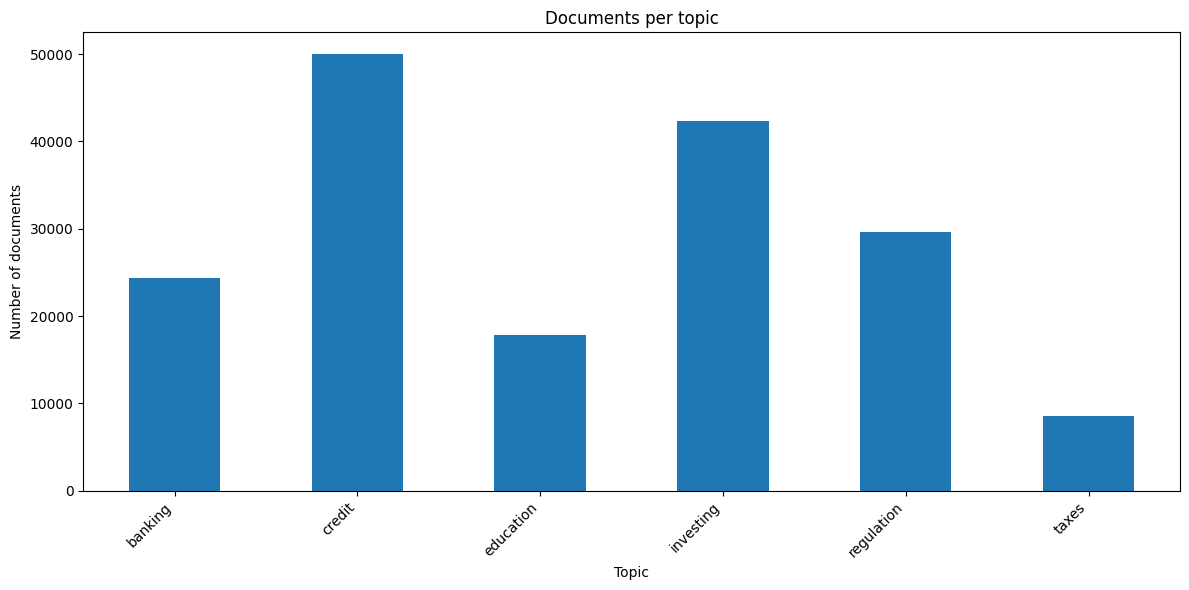

In [483]:
import ast

def normalize_topics(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return x if isinstance(x, list) else []

tags_docs["top3_topics"] = tags_docs["top3_topics"].apply(normalize_topics)

# Count "documents containing topic" (use row index as document id)
exploded = tags_docs[["top3_topics"]].explode("top3_topics").dropna(subset=["top3_topics"])
doc_topic_counts = (
    exploded.reset_index()                      # index = document id
    .groupby("top3_topics")["index"].nunique()  # number of docs containing the topic
)

plt.figure(figsize=(12, 6))
doc_topic_counts.plot(kind="bar")
plt.ylabel("Number of documents")
plt.xlabel("Topic")
plt.title("Documents per topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


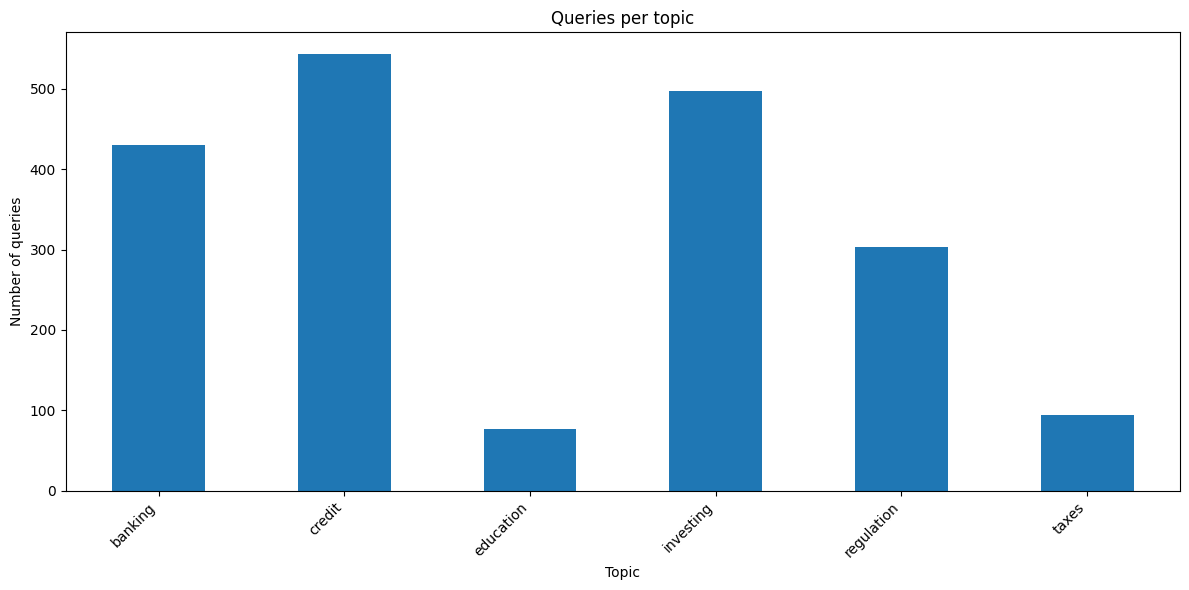

In [485]:
import ast


tags_queries["top3_topics"] = tags_queries["top3_topics"].apply(normalize_topics)

# Count "documents containing topic" (use row index as document id)
exploded = tags_queries[["top3_topics"]].explode("top3_topics").dropna(subset=["top3_topics"])
doc_topic_counts = (
    exploded.reset_index()                      # index = document id
    .groupby("top3_topics")["index"].nunique()  # number of docs containing the topic
)

plt.figure(figsize=(12, 6))
doc_topic_counts.plot(kind="bar")
plt.ylabel("Number of queries")
plt.xlabel("Topic")
plt.title("Queries per topic")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [486]:
print(tags_docs["top3_topics"].head(3))
print(type(tags_docs["top3_topics"].iloc[0]))


0     [education, investing, credit]
1      [credit, regulation, banking]
2    [regulation, credit, investing]
Name: top3_topics, dtype: object
<class 'list'>


In [487]:
sentiment_df = pd.read_csv('./sentiment_df.csv')

In [488]:
sentiment_df

,Unnamed: 0,docno,sentiment,confidence
0,0,3,positive,0.740279
1,1,31,positive,0.911631
2,2,56,positive,0.881663
3,3,59,positive,0.922108
4,4,63,positive,0.936929
...,...,...,...,...
57633,57633,599946,positive,0.875183
57634,57634,599953,positive,0.859306
57635,57635,599966,neutral,0.831728
57636,57636,599975,positive,0.865308


In [489]:
docs1['docno']= docs1['docno'].astype('int64')
tags_docs['docno'] = tags_docs['docno'].astype('int64')
tags_docs = pd.merge(tags_docs, docs1, on='docno', how='inner')


In [490]:
tags_docs

,Unnamed: 0,docno,top3_topics,top3_scores,text
0,0,3,"[education, investing, credit]","[0.9491311311721802, 0.808022677898407, 0.3284...",I'm not saying I don't like the idea of on-the...
1,1,31,"[credit, regulation, banking]","[0.9008433818817139, 0.6907130479812622, 0.665...",So nothing preventing false ratings besides ad...
2,2,56,"[regulation, credit, investing]","[0.9034470915794373, 0.5898595452308655, 0.173...",You can never use a health FSA for individual ...
3,3,59,"[credit, investing, regulation]","[0.9901934862136841, 0.595706582069397, 0.2746...",Samsung created the LCD and other flat screen ...
4,4,63,"[regulation, investing, banking]","[0.7835092544555664, 0.4374961853027344, 0.216...",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...
57633,57633,599946,"[regulation, taxes, credit]","[0.8661596179008484, 0.36633968353271484, 0.26...","&gt;Well, first off, the roads are more than j..."
57634,57634,599953,"[credit, taxes, regulation]","[0.5913487076759338, 0.5441805720329285, 0.386...",Yes they do. There are billions and billions s...
57635,57635,599966,"[regulation, credit, investing]","[0.3586137592792511, 0.3065590560436249, 0.273...",&gt;It's biggly sad you don't understand human...
57636,57636,599975,"[education, regulation, credit]","[0.3447442948818207, 0.18888334929943085, 0.14...","""Did your CTO let a major group use """"admin/ad..."


In [491]:
sentiment_df['docno'] = sentiment_df['docno'].astype('int64')

sentiment_df = pd.merge(sentiment_df, tags_docs, on='docno', how='inner')
sentiment_df

,Unnamed: 0_x,docno,sentiment,confidence,Unnamed: 0_y,top3_topics,top3_scores,text
0,0,3,positive,0.740279,0,"[education, investing, credit]","[0.9491311311721802, 0.808022677898407, 0.3284...",I'm not saying I don't like the idea of on-the...
1,1,31,positive,0.911631,1,"[credit, regulation, banking]","[0.9008433818817139, 0.6907130479812622, 0.665...",So nothing preventing false ratings besides ad...
2,2,56,positive,0.881663,2,"[regulation, credit, investing]","[0.9034470915794373, 0.5898595452308655, 0.173...",You can never use a health FSA for individual ...
3,3,59,positive,0.922108,3,"[credit, investing, regulation]","[0.9901934862136841, 0.595706582069397, 0.2746...",Samsung created the LCD and other flat screen ...
4,4,63,positive,0.936929,4,"[regulation, investing, banking]","[0.7835092544555664, 0.4374961853027344, 0.216...",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...,...,...,...
57633,57633,599946,positive,0.875183,57633,"[regulation, taxes, credit]","[0.8661596179008484, 0.36633968353271484, 0.26...","&gt;Well, first off, the roads are more than j..."
57634,57634,599953,positive,0.859306,57634,"[credit, taxes, regulation]","[0.5913487076759338, 0.5441805720329285, 0.386...",Yes they do. There are billions and billions s...
57635,57635,599966,neutral,0.831728,57635,"[regulation, credit, investing]","[0.3586137592792511, 0.3065590560436249, 0.273...",&gt;It's biggly sad you don't understand human...
57636,57636,599975,positive,0.865308,57636,"[education, regulation, credit]","[0.3447442948818207, 0.18888334929943085, 0.14...","""Did your CTO let a major group use """"admin/ad..."


In [492]:
sentiment_df

,Unnamed: 0_x,docno,sentiment,confidence,Unnamed: 0_y,top3_topics,top3_scores,text
0,0,3,positive,0.740279,0,"[education, investing, credit]","[0.9491311311721802, 0.808022677898407, 0.3284...",I'm not saying I don't like the idea of on-the...
1,1,31,positive,0.911631,1,"[credit, regulation, banking]","[0.9008433818817139, 0.6907130479812622, 0.665...",So nothing preventing false ratings besides ad...
2,2,56,positive,0.881663,2,"[regulation, credit, investing]","[0.9034470915794373, 0.5898595452308655, 0.173...",You can never use a health FSA for individual ...
3,3,59,positive,0.922108,3,"[credit, investing, regulation]","[0.9901934862136841, 0.595706582069397, 0.2746...",Samsung created the LCD and other flat screen ...
4,4,63,positive,0.936929,4,"[regulation, investing, banking]","[0.7835092544555664, 0.4374961853027344, 0.216...",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...,...,...,...
57633,57633,599946,positive,0.875183,57633,"[regulation, taxes, credit]","[0.8661596179008484, 0.36633968353271484, 0.26...","&gt;Well, first off, the roads are more than j..."
57634,57634,599953,positive,0.859306,57634,"[credit, taxes, regulation]","[0.5913487076759338, 0.5441805720329285, 0.386...",Yes they do. There are billions and billions s...
57635,57635,599966,neutral,0.831728,57635,"[regulation, credit, investing]","[0.3586137592792511, 0.3065590560436249, 0.273...",&gt;It's biggly sad you don't understand human...
57636,57636,599975,positive,0.865308,57636,"[education, regulation, credit]","[0.3447442948818207, 0.18888334929943085, 0.14...","""Did your CTO let a major group use """"admin/ad..."


In [493]:
df_ner

,docno,entities
0,3,[U. S]
1,31,"[DFA, CDO]"
2,56,"[FSA, FSA, FSA, FSA]"
3,59,"[Samsung, O, Samsung, Samsung, Samsung]"
4,63,"[SEC, 501, Regulation D, Em, ##ee Re, ##ent In..."
...,...,...
57633,599946,[]
57634,599953,[US]
57635,599966,[]
57636,599975,"[CT, CT, T]"


In [494]:
df_ner['docno'] = df_ner['docno'].astype('int64')

df_total = pd.merge(df_ner, sentiment_df, on='docno', how='inner')
df_total

,docno,entities,Unnamed: 0_x,sentiment,confidence,Unnamed: 0_y,top3_topics,top3_scores,text
0,3,[U. S],0,positive,0.740279,0,"[education, investing, credit]","[0.9491311311721802, 0.808022677898407, 0.3284...",I'm not saying I don't like the idea of on-the...
1,31,"[DFA, CDO]",1,positive,0.911631,1,"[credit, regulation, banking]","[0.9008433818817139, 0.6907130479812622, 0.665...",So nothing preventing false ratings besides ad...
2,56,"[FSA, FSA, FSA, FSA]",2,positive,0.881663,2,"[regulation, credit, investing]","[0.9034470915794373, 0.5898595452308655, 0.173...",You can never use a health FSA for individual ...
3,59,"[Samsung, O, Samsung, Samsung, Samsung]",3,positive,0.922108,3,"[credit, investing, regulation]","[0.9901934862136841, 0.595706582069397, 0.2746...",Samsung created the LCD and other flat screen ...
4,63,"[SEC, 501, Regulation D, Em, ##ee Re, ##ent In...",4,positive,0.936929,4,"[regulation, investing, banking]","[0.7835092544555664, 0.4374961853027344, 0.216...",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...,...,...,...,...
57633,599946,[],57633,positive,0.875183,57633,"[regulation, taxes, credit]","[0.8661596179008484, 0.36633968353271484, 0.26...","&gt;Well, first off, the roads are more than j..."
57634,599953,[US],57634,positive,0.859306,57634,"[credit, taxes, regulation]","[0.5913487076759338, 0.5441805720329285, 0.386...",Yes they do. There are billions and billions s...
57635,599966,[],57635,neutral,0.831728,57635,"[regulation, credit, investing]","[0.3586137592792511, 0.3065590560436249, 0.273...",&gt;It's biggly sad you don't understand human...
57636,599975,"[CT, CT, T]",57636,positive,0.865308,57636,"[education, regulation, credit]","[0.3447442948818207, 0.18888334929943085, 0.14...","""Did your CTO let a major group use """"admin/ad..."


In [495]:
df_total = df_total.drop(columns=df_total.columns[df_total.columns.str.startswith("Unnamed")])
df_total

,docno,entities,sentiment,confidence,top3_topics,top3_scores,text
0,3,[U. S],positive,0.740279,"[education, investing, credit]","[0.9491311311721802, 0.808022677898407, 0.3284...",I'm not saying I don't like the idea of on-the...
1,31,"[DFA, CDO]",positive,0.911631,"[credit, regulation, banking]","[0.9008433818817139, 0.6907130479812622, 0.665...",So nothing preventing false ratings besides ad...
2,56,"[FSA, FSA, FSA, FSA]",positive,0.881663,"[regulation, credit, investing]","[0.9034470915794373, 0.5898595452308655, 0.173...",You can never use a health FSA for individual ...
3,59,"[Samsung, O, Samsung, Samsung, Samsung]",positive,0.922108,"[credit, investing, regulation]","[0.9901934862136841, 0.595706582069397, 0.2746...",Samsung created the LCD and other flat screen ...
4,63,"[SEC, 501, Regulation D, Em, ##ee Re, ##ent In...",positive,0.936929,"[regulation, investing, banking]","[0.7835092544555664, 0.4374961853027344, 0.216...",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...,...,...
57633,599946,[],positive,0.875183,"[regulation, taxes, credit]","[0.8661596179008484, 0.36633968353271484, 0.26...","&gt;Well, first off, the roads are more than j..."
57634,599953,[US],positive,0.859306,"[credit, taxes, regulation]","[0.5913487076759338, 0.5441805720329285, 0.386...",Yes they do. There are billions and billions s...
57635,599966,[],neutral,0.831728,"[regulation, credit, investing]","[0.3586137592792511, 0.3065590560436249, 0.273...",&gt;It's biggly sad you don't understand human...
57636,599975,"[CT, CT, T]",positive,0.865308,"[education, regulation, credit]","[0.3447442948818207, 0.18888334929943085, 0.14...","""Did your CTO let a major group use """"admin/ad..."


In [496]:
df_total = df_total.drop(columns=["top3_scores", "confidence"])

In [497]:
df_total

,docno,entities,sentiment,top3_topics,text
0,3,[U. S],positive,"[education, investing, credit]",I'm not saying I don't like the idea of on-the...
1,31,"[DFA, CDO]",positive,"[credit, regulation, banking]",So nothing preventing false ratings besides ad...
2,56,"[FSA, FSA, FSA, FSA]",positive,"[regulation, credit, investing]",You can never use a health FSA for individual ...
3,59,"[Samsung, O, Samsung, Samsung, Samsung]",positive,"[credit, investing, regulation]",Samsung created the LCD and other flat screen ...
4,63,"[SEC, 501, Regulation D, Em, ##ee Re, ##ent In...",positive,"[regulation, investing, banking]",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...
57633,599946,[],positive,"[regulation, taxes, credit]","&gt;Well, first off, the roads are more than j..."
57634,599953,[US],positive,"[credit, taxes, regulation]",Yes they do. There are billions and billions s...
57635,599966,[],neutral,"[regulation, credit, investing]",&gt;It's biggly sad you don't understand human...
57636,599975,"[CT, CT, T]",positive,"[education, regulation, credit]","""Did your CTO let a major group use """"admin/ad..."


### Query unification


In [498]:
display(queries)

,qid,query
0,4641,Where should I park my rainy-day / emergency f...
1,5503,Tax considerations for selling a property belo...
2,7803,Can the Delta be used to calculate the option ...
3,7017,Basic Algorithmic Trading Strategy
4,10152,What does a high operating margin but a small ...
...,...,...
643,4102,How can I determine if my rate of return is “g...
644,3566,Where can I buy stocks if I only want to inves...
645,94,Using credit card points to pay for tax deduct...
646,2551,How to find cheaper alternatives to a traditio...


In [499]:
sentiment_q

,qid,sentiment,confidence
0,4641,positive,0.771040
1,5503,positive,0.924082
2,7803,positive,0.937387
3,7017,positive,0.941313
4,10152,positive,0.860820
...,...,...,...
643,4102,positive,0.863959
644,3566,positive,0.933026
645,94,positive,0.916428
646,2551,positive,0.825843


In [500]:
queries['qid'] = queries['qid'].astype('int64')
sentiment_q['qid'] = sentiment_q['qid'].astype('int64')
df_ner_q['qid'] = df_ner_q['qid'].astype('int64')


queries_sentiment = pd.merge(queries, sentiment_q, on='qid', how='inner')
queries_sentiment_ner = pd.merge(queries_sentiment, df_ner_q, on='qid', how='inner')


In [501]:
tags_queries

,Unnamed: 0,qids,top3_topics,top3_scores
0,0,4641,"[investing, banking, credit]","[0.4287841320037842, 0.3427979648113251, 0.056..."
1,1,5503,"[taxes, regulation, investing]","[0.9585870504379272, 0.04324774071574211, 0.01..."
2,2,7803,"[investing, banking, credit]","[0.8117352724075317, 0.3381434679031372, 0.306..."
3,3,7017,"[investing, credit, banking]","[0.5106886029243469, 0.2827812731266022, 0.083..."
4,4,10152,"[investing, banking, credit]","[0.461930513381958, 0.3720417022705078, 0.0511..."
...,...,...,...,...
643,643,4102,"[investing, banking, credit]","[0.9342626929283142, 0.4654264748096466, 0.365..."
644,644,3566,"[investing, credit, banking]","[0.8451239466667175, 0.06888141483068466, 0.02..."
645,645,94,"[credit, taxes, regulation]","[0.9780347347259521, 0.12368687987327576, 0.01..."
646,646,2551,"[investing, credit, regulation]","[0.0919739380478859, 0.0036584404297173023, 0...."


In [502]:
tags_queries['qid'] = tags_queries['qids'].astype('int64')
queries_total = pd.merge(queries_sentiment_ner, tags_queries, on='qid', how='inner')

In [503]:
queries_total

,qid,query,sentiment,confidence,entities,Unnamed: 0,qids,top3_topics,top3_scores
0,4641,Where should I park my rainy-day / emergency f...,positive,0.771040,[],0,4641,"[investing, banking, credit]","[0.4287841320037842, 0.3427979648113251, 0.056..."
1,5503,Tax considerations for selling a property belo...,positive,0.924082,[],1,5503,"[taxes, regulation, investing]","[0.9585870504379272, 0.04324774071574211, 0.01..."
2,7803,Can the Delta be used to calculate the option ...,positive,0.937387,[US],2,7803,"[investing, banking, credit]","[0.8117352724075317, 0.3381434679031372, 0.306..."
3,7017,Basic Algorithmic Trading Strategy,positive,0.941313,[],3,7017,"[investing, credit, banking]","[0.5106886029243469, 0.2827812731266022, 0.083..."
4,10152,What does a high operating margin but a small ...,positive,0.860820,"[CT, CT, T]",4,10152,"[investing, banking, credit]","[0.461930513381958, 0.3720417022705078, 0.0511..."
...,...,...,...,...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,0.735973,[],641,10812,"[taxes, regulation, credit]","[0.9465392231941223, 0.06210822984576225, 0.00..."
242,3512,"As an employee, when is it inappropriate to re...",positive,0.602001,[US],642,3512,"[credit, investing, education]","[0.5746724009513855, 0.3845781981945038, 0.272..."
243,4102,How can I determine if my rate of return is “g...,positive,0.863959,[],643,4102,"[investing, banking, credit]","[0.9342626929283142, 0.4654264748096466, 0.365..."
244,3566,Where can I buy stocks if I only want to inves...,positive,0.933026,"[CT, CT, T]",644,3566,"[investing, credit, banking]","[0.8451239466667175, 0.06888141483068466, 0.02..."


In [504]:
queries_total = queries_total.drop(columns=["qids"])


In [505]:
queries_total

,qid,query,sentiment,confidence,entities,Unnamed: 0,top3_topics,top3_scores
0,4641,Where should I park my rainy-day / emergency f...,positive,0.771040,[],0,"[investing, banking, credit]","[0.4287841320037842, 0.3427979648113251, 0.056..."
1,5503,Tax considerations for selling a property belo...,positive,0.924082,[],1,"[taxes, regulation, investing]","[0.9585870504379272, 0.04324774071574211, 0.01..."
2,7803,Can the Delta be used to calculate the option ...,positive,0.937387,[US],2,"[investing, banking, credit]","[0.8117352724075317, 0.3381434679031372, 0.306..."
3,7017,Basic Algorithmic Trading Strategy,positive,0.941313,[],3,"[investing, credit, banking]","[0.5106886029243469, 0.2827812731266022, 0.083..."
4,10152,What does a high operating margin but a small ...,positive,0.860820,"[CT, CT, T]",4,"[investing, banking, credit]","[0.461930513381958, 0.3720417022705078, 0.0511..."
...,...,...,...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,0.735973,[],641,"[taxes, regulation, credit]","[0.9465392231941223, 0.06210822984576225, 0.00..."
242,3512,"As an employee, when is it inappropriate to re...",positive,0.602001,[US],642,"[credit, investing, education]","[0.5746724009513855, 0.3845781981945038, 0.272..."
243,4102,How can I determine if my rate of return is “g...,positive,0.863959,[],643,"[investing, banking, credit]","[0.9342626929283142, 0.4654264748096466, 0.365..."
244,3566,Where can I buy stocks if I only want to inves...,positive,0.933026,"[CT, CT, T]",644,"[investing, credit, banking]","[0.8451239466667175, 0.06888141483068466, 0.02..."


In [506]:
queries_total = queries_total.drop(columns=queries_total.columns[queries_total.columns.str.startswith("Unnamed")])
queries_total

,qid,query,sentiment,confidence,entities,top3_topics,top3_scores
0,4641,Where should I park my rainy-day / emergency f...,positive,0.771040,[],"[investing, banking, credit]","[0.4287841320037842, 0.3427979648113251, 0.056..."
1,5503,Tax considerations for selling a property belo...,positive,0.924082,[],"[taxes, regulation, investing]","[0.9585870504379272, 0.04324774071574211, 0.01..."
2,7803,Can the Delta be used to calculate the option ...,positive,0.937387,[US],"[investing, banking, credit]","[0.8117352724075317, 0.3381434679031372, 0.306..."
3,7017,Basic Algorithmic Trading Strategy,positive,0.941313,[],"[investing, credit, banking]","[0.5106886029243469, 0.2827812731266022, 0.083..."
4,10152,What does a high operating margin but a small ...,positive,0.860820,"[CT, CT, T]","[investing, banking, credit]","[0.461930513381958, 0.3720417022705078, 0.0511..."
...,...,...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,0.735973,[],"[taxes, regulation, credit]","[0.9465392231941223, 0.06210822984576225, 0.00..."
242,3512,"As an employee, when is it inappropriate to re...",positive,0.602001,[US],"[credit, investing, education]","[0.5746724009513855, 0.3845781981945038, 0.272..."
243,4102,How can I determine if my rate of return is “g...,positive,0.863959,[],"[investing, banking, credit]","[0.9342626929283142, 0.4654264748096466, 0.365..."
244,3566,Where can I buy stocks if I only want to inves...,positive,0.933026,"[CT, CT, T]","[investing, credit, banking]","[0.8451239466667175, 0.06888141483068466, 0.02..."


In [555]:
# queries_total = queries_total.drop(columns=["top3_scores", "confidence"])
queries_total

,qid,query,sentiment,entities,top3_topics
0,4641,Where should I park my rainy-day / emergency f...,positive,[],"[investing, banking, credit]"
1,5503,Tax considerations for selling a property belo...,positive,[],"[taxes, regulation, investing]"
2,7803,Can the Delta be used to calculate the option ...,positive,[US],"[investing, banking, credit]"
3,7017,Basic Algorithmic Trading Strategy,positive,[],"[investing, credit, banking]"
4,10152,What does a high operating margin but a small ...,positive,"[CT, CT, T]","[investing, banking, credit]"
...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,[],"[taxes, regulation, credit]"
242,3512,"As an employee, when is it inappropriate to re...",positive,[US],"[credit, investing, education]"
243,4102,How can I determine if my rate of return is “g...,positive,[],"[investing, banking, credit]"
244,3566,Where can I buy stocks if I only want to inves...,positive,"[CT, CT, T]","[investing, credit, banking]"


In [270]:
queries_total.to_csv("queries_total.csv")
df_total.to_csv("df_total.csv")

In [556]:
def norm_tok(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", "_", x)
    x = re.sub(r"[^a-z0-9_]", "", x)
    return x

def row_to_dict(row):
    ents = [norm_tok(e) for e in row["entities"] if str(e).strip()]
    tops = [norm_tok(t) for t in row["top3_topics"] if str(t).strip()]

    sent = norm_tok(row["sentiment"])

    return {
        "docno": str(row["docno"]),
        "text": row["text"],
        "sent_f": f"sent_{sent}",
        "ent_f": " ".join(f"ent_{e}" for e in ents),
        "topic_f": " ".join(f"top_{t}" for t in tops),
    }


In [557]:
docs_iter = (row_to_dict(r) for _, r in df_total.iterrows())

indexer = pt.IterDictIndexer(
    "./terrier_index",
    meta={"docno": 50},
    fields=["text", "sent_f", "ent_f", "topic_f"],
    overwrite=True
)
index_ref = indexer.index(docs_iter)


21:08:48.956 [ForkJoinPool-23-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
21:09:00.879 [ForkJoinPool-23-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents


In [569]:
df_docs = df_total.copy()
df_docs["docno"] = df_docs["docno"].astype(str)

In [570]:
queries_prepared = queries_total.copy()
queries_prepared.rename(columns={'sentiment': 'sentiment_q', 'entities': 'entities_q', 'top3_topics': 'topics_q'}, inplace=True)
queries_prepared

,qid,query,sentiment_q,entities_q,topics_q
0,4641,Where should I park my rainy-day / emergency f...,positive,[],"[investing, banking, credit]"
1,5503,Tax considerations for selling a property belo...,positive,[],"[taxes, regulation, investing]"
2,7803,Can the Delta be used to calculate the option ...,positive,[US],"[investing, banking, credit]"
3,7017,Basic Algorithmic Trading Strategy,positive,[],"[investing, credit, banking]"
4,10152,What does a high operating margin but a small ...,positive,"[CT, CT, T]","[investing, banking, credit]"
...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,[],"[taxes, regulation, credit]"
242,3512,"As an employee, when is it inappropriate to re...",positive,[US],"[credit, investing, education]"
243,4102,How can I determine if my rate of return is “g...,positive,[],"[investing, banking, credit]"
244,3566,Where can I buy stocks if I only want to inves...,positive,"[CT, CT, T]","[investing, credit, banking]"


In [571]:
br = pt.BatchRetrieve(index_ref, wmodel="BM25", num_results=1000)

ALLOWED = {
    "positive": {"positive", "neutral"},
    "neutral":  {"positive", "neutral", "negative"},
    "negative": {"negative", "neutral"},
}

def hard_filter_stage(res: pd.DataFrame) -> pd.DataFrame:
    # res contains qid, docno, score, rank, query, plus your query-side fields if present
    # attach doc metadata
    out = res.merge(
        df_docs[["docno", "sentiment", "entities_norm", "topics_norm"]],
        on="docno",
        how="left",
        suffixes=("", "_doc")
    )

    # build per-row checks
    def passes(row):
        qsent = str(row["sentiment_q"]).lower()   # rename as needed
        dsent = str(row["sentiment"]).lower()

        # sentiment gate
        if dsent not in ALLOWED.get(qsent, {"positive","neutral","negative"}):
            return False

        # NER gate (AND)
        qents = row["entities_q"] or set()
        if len(qents) > 0 and not set(qents).issubset(set(row["entities_norm"] or set())):
            return False

        # topic gate (OR)
        qt = row["topics_q"] or set()
        if len(qt) > 0 and len(set(qt) & set(row["topics_norm"] or set())) == 0:
            return False

        return True

    out = out[out.apply(passes, axis=1)]
    # re-rank after filtering (optional but usually desirable)
    out = out.sort_values(["qid", "score"], ascending=[True, False])
    out["rank"] = out.groupby("qid").cumcount()
    return out

/tmp/ipython-input-3323563806.py:1: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  br = pt.BatchRetrieve(index_ref, wmodel="BM25", num_results=1000)


In [572]:
queries_prepared

,qid,query,sentiment_q,entities_q,topics_q
0,4641,Where should I park my rainy-day / emergency f...,positive,[],"[investing, banking, credit]"
1,5503,Tax considerations for selling a property belo...,positive,[],"[taxes, regulation, investing]"
2,7803,Can the Delta be used to calculate the option ...,positive,[US],"[investing, banking, credit]"
3,7017,Basic Algorithmic Trading Strategy,positive,[],"[investing, credit, banking]"
4,10152,What does a high operating margin but a small ...,positive,"[CT, CT, T]","[investing, banking, credit]"
...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,[],"[taxes, regulation, credit]"
242,3512,"As an employee, when is it inappropriate to re...",positive,[US],"[credit, investing, education]"
243,4102,How can I determine if my rate of return is “g...,positive,[],"[investing, banking, credit]"
244,3566,Where can I buy stocks if I only want to inves...,positive,"[CT, CT, T]","[investing, credit, banking]"


In [573]:
def normalize_set(items):
    if isinstance(items, list):
        return {norm_tok(x) for x in items if str(x).strip()}
    return set()
df_docs["entities_norm"] = df_docs["entities"].apply(normalize_set)
df_docs["topics_norm"] = df_docs["top3_topics"].apply(normalize_set)

# Also normalize query side to match
queries_prepared["entities_q"] = queries_prepared["entities_q"].apply(normalize_set)
queries_prepared["topics_q"] = queries_prepared["topics_q"].apply(normalize_set)

queries_prepared

,qid,query,sentiment_q,entities_q,topics_q
0,4641,Where should I park my rainy-day / emergency f...,positive,{},"{credit, investing, banking}"
1,5503,Tax considerations for selling a property belo...,positive,{},"{regulation, investing, taxes}"
2,7803,Can the Delta be used to calculate the option ...,positive,{us},"{credit, investing, banking}"
3,7017,Basic Algorithmic Trading Strategy,positive,{},"{credit, investing, banking}"
4,10152,What does a high operating margin but a small ...,positive,"{t, ct}","{credit, investing, banking}"
...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,{},"{regulation, credit, taxes}"
242,3512,"As an employee, when is it inappropriate to re...",positive,{us},"{education, credit, investing}"
243,4102,How can I determine if my rate of return is “g...,positive,{},"{credit, investing, banking}"
244,3566,Where can I buy stocks if I only want to inves...,positive,"{t, ct}","{credit, investing, banking}"


In [574]:

br = pt.terrier.Retriever(index_ref, wmodel="BM25")
pipeBM25 = br >> pt.apply.generic(hard_filter_stage)
results_adv = pipeBM25(queries_prepared)


In [578]:
tfidf_adv = pt.terrier.Retriever(index_ref, wmodel="TF_IDF")
pipeTFIDF = tfidf_adv >> pt.apply.generic(hard_filter_stage)
results_adv_tf = pipeTFIDF(queries_prepared)


In [576]:
exp_adv = pt.Experiment(
    [pipeBM25, pipeTFIDF],
    queries_prepared,
    qrels,
    eval_metrics=metrics,
    names=["BM25+filtering", "TF-IDF+filtering"],
    #baseline=0,
    verbose=True,
)

/usr/local/lib/python3.12/dist-packages/pyterrier/_evaluation/_validation.py:43: UserWarning: Transformer BM25+filtering ((TerrierRetr(BM25) >> pt.apply.generic())) at position 0 failed to validate: Cannot determine outputs for (TerrierRetr(BM25) >> pt.apply.generic()) with inputs: ['qid', 'query', 'sentiment_q', 'entities_q', 'topics_q'] - if your pipeline works, set validate='ignore' to remove this warning, or add transform_output method to the transformers in this pipeline to clarify how it works. See https://pyterrier.readthedocs.io/en/latest/troubleshooting/inspection.html for more information.
  warn(
/usr/local/lib/python3.12/dist-packages/pyterrier/_evaluation/_validation.py:43: UserWarning: Transformer TF-IDF+filtering ((TerrierRetr(TF_IDF) >> pt.apply.generic())) at position 1 failed to validate: Cannot determine outputs for (TerrierRetr(TF_IDF) >> pt.apply.generic()) with inputs: ['qid', 'query', 'sentiment_q', 'entities_q', 'topics_q'] - if your pipeline works, set validate

pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

In [577]:
exp_adv

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,BM25+filtering,0.137630,0.158537,0.065041,0.043902,0.156131,0.205725,0.146335,0.166655
1,TF-IDF+filtering,0.139034,0.162602,0.065854,0.044715,0.160400,0.209790,0.149232,0.169396


# Only topics

In [595]:
queries_prepared

,qid,query,sentiment_q,entities_q,topics_q
0,4641,Where should I park my rainy-day / emergency f...,positive,{},"{credit, investing, banking}"
1,5503,Tax considerations for selling a property belo...,positive,{},"{regulation, investing, taxes}"
2,7803,Can the Delta be used to calculate the option ...,positive,{us},"{credit, investing, banking}"
3,7017,Basic Algorithmic Trading Strategy,positive,{},"{credit, investing, banking}"
4,10152,What does a high operating margin but a small ...,positive,"{t, ct}","{credit, investing, banking}"
...,...,...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,positive,{},"{regulation, credit, taxes}"
242,3512,"As an employee, when is it inappropriate to re...",positive,{us},"{education, credit, investing}"
243,4102,How can I determine if my rate of return is “g...,positive,{},"{credit, investing, banking}"
244,3566,Where can I buy stocks if I only want to inves...,positive,"{t, ct}","{credit, investing, banking}"


In [596]:
queries_topics = queries_prepared.drop(columns=["sentiment_q", "entities_q"])
queries_topics

,qid,query,topics_q
0,4641,Where should I park my rainy-day / emergency f...,"{credit, investing, banking}"
1,5503,Tax considerations for selling a property belo...,"{regulation, investing, taxes}"
2,7803,Can the Delta be used to calculate the option ...,"{credit, investing, banking}"
3,7017,Basic Algorithmic Trading Strategy,"{credit, investing, banking}"
4,10152,What does a high operating margin but a small ...,"{credit, investing, banking}"
...,...,...,...
241,10812,Is is possible to dispute IRS underpayment pen...,"{regulation, credit, taxes}"
242,3512,"As an employee, when is it inappropriate to re...","{education, credit, investing}"
243,4102,How can I determine if my rate of return is “g...,"{credit, investing, banking}"
244,3566,Where can I buy stocks if I only want to inves...,"{credit, investing, banking}"


In [611]:
df_total

,docno,entities,sentiment,top3_topics,text
0,3,[U. S],positive,"[education, investing, credit]",I'm not saying I don't like the idea of on-the...
1,31,"[DFA, CDO]",positive,"[credit, regulation, banking]",So nothing preventing false ratings besides ad...
2,56,"[FSA, FSA, FSA, FSA]",positive,"[regulation, credit, investing]",You can never use a health FSA for individual ...
3,59,"[Samsung, O, Samsung, Samsung, Samsung]",positive,"[credit, investing, regulation]",Samsung created the LCD and other flat screen ...
4,63,"[SEC, 501, Regulation D, Em, ##ee Re, ##ent In...",positive,"[regulation, investing, banking]",Here are the SEC requirements: The federal sec...
...,...,...,...,...,...
57633,599946,[],positive,"[regulation, taxes, credit]","&gt;Well, first off, the roads are more than j..."
57634,599953,[US],positive,"[credit, taxes, regulation]",Yes they do. There are billions and billions s...
57635,599966,[],neutral,"[regulation, credit, investing]",&gt;It's biggly sad you don't understand human...
57636,599975,"[CT, CT, T]",positive,"[education, regulation, credit]","""Did your CTO let a major group use """"admin/ad..."


In [617]:
df_total_topics = df_total.drop(columns=["sentiment", "entities"])
df_total_topics

,docno,top3_topics,text
0,3,"[education, investing, credit]",I'm not saying I don't like the idea of on-the...
1,31,"[credit, regulation, banking]",So nothing preventing false ratings besides ad...
2,56,"[regulation, credit, investing]",You can never use a health FSA for individual ...
3,59,"[credit, investing, regulation]",Samsung created the LCD and other flat screen ...
4,63,"[regulation, investing, banking]",Here are the SEC requirements: The federal sec...
...,...,...,...
57633,599946,"[regulation, taxes, credit]","&gt;Well, first off, the roads are more than j..."
57634,599953,"[credit, taxes, regulation]",Yes they do. There are billions and billions s...
57635,599966,"[regulation, credit, investing]",&gt;It's biggly sad you don't understand human...
57636,599975,"[education, regulation, credit]","""Did your CTO let a major group use """"admin/ad..."


In [618]:
df_total_topics["topics_norm"] = df_total_topics["top3_topics"].apply(normalize_set)
df_total_topics

,docno,top3_topics,text,topics_norm
0,3,"[education, investing, credit]",I'm not saying I don't like the idea of on-the...,"{education, credit, investing}"
1,31,"[credit, regulation, banking]",So nothing preventing false ratings besides ad...,"{credit, banking, regulation}"
2,56,"[regulation, credit, investing]",You can never use a health FSA for individual ...,"{credit, investing, regulation}"
3,59,"[credit, investing, regulation]",Samsung created the LCD and other flat screen ...,"{credit, investing, regulation}"
4,63,"[regulation, investing, banking]",Here are the SEC requirements: The federal sec...,"{investing, banking, regulation}"
...,...,...,...,...
57633,599946,"[regulation, taxes, credit]","&gt;Well, first off, the roads are more than j...","{taxes, credit, regulation}"
57634,599953,"[credit, taxes, regulation]",Yes they do. There are billions and billions s...,"{regulation, credit, taxes}"
57635,599966,"[regulation, credit, investing]",&gt;It's biggly sad you don't understand human...,"{credit, investing, regulation}"
57636,599975,"[education, regulation, credit]","""Did your CTO let a major group use """"admin/ad...","{education, credit, regulation}"


In [619]:
df_total_topics = df_total_topics.drop(columns=["top3_topics"])


In [628]:
df_total_topics

,docno,text,topics_norm
0,3,I'm not saying I don't like the idea of on-the...,"{education, credit, investing}"
1,31,So nothing preventing false ratings besides ad...,"{credit, banking, regulation}"
2,56,You can never use a health FSA for individual ...,"{credit, investing, regulation}"
3,59,Samsung created the LCD and other flat screen ...,"{credit, investing, regulation}"
4,63,Here are the SEC requirements: The federal sec...,"{investing, banking, regulation}"
...,...,...,...
57633,599946,"&gt;Well, first off, the roads are more than j...","{taxes, credit, regulation}"
57634,599953,Yes they do. There are billions and billions s...,"{regulation, credit, taxes}"
57635,599966,&gt;It's biggly sad you don't understand human...,"{credit, investing, regulation}"
57636,599975,"""Did your CTO let a major group use """"admin/ad...","{education, credit, regulation}"


In [629]:
def row_to_dict_topics(row):
    tops = [norm_tok(t) for t in row["topics_norm"] if str(t).strip()]

    return {
        "docno": str(row["docno"]),
        "text": row["text"],
        "topic_f": " ".join(f"top_{t}" for t in tops),
    }


In [630]:
docs_iter = (row_to_dict_topics(r) for _, r in df_total_topics.iterrows())

indexer = pt.IterDictIndexer(
    "./terrier_index",
    meta={"docno": 50},
    fields=["text", "topic_f"],
    overwrite=True
)
index_ref = indexer.index(docs_iter)


21:20:36.214 [ForkJoinPool-27-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (7915) - further warnings are suppressed
21:20:48.261 [ForkJoinPool-27-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 39 empty documents


In [631]:
def to_set(v):
    if v is None:
        return set()
    if isinstance(v, set):
        return v
    if isinstance(v, list):
        return {norm_tok(x) for x in v if str(x).strip()}
    if isinstance(v, str):
        return {norm_tok(v)} if v.strip() else set()
    return {norm_tok(v)}


In [591]:
# df_total['docno'] = df_total['docno'].astype(str)

In [641]:
def topic_only_filter_stage(res):
    topics_ref = df_total_topics[['docno', 'topics_norm']].copy()
    topics_ref['docno'] = topics_ref['docno'].astype(str)

    out = res.copy()
    out['docno'] = out['docno'].astype(str)

    out = out.merge(topics_ref, on='docno', how='left')

    def passes(row):
        qt = row.get('topics_q')
        if not isinstance(qt, set):
            qt = set(qt) if isinstance(qt, (list, tuple)) else set()

        # Doc topics (set)
        dt = row.get('topics_norm')
        if not isinstance(dt, set):
            dt = set(dt) if isinstance(dt, (list, tuple)) else set()

        if len(qt) > 0 and len(qt & dt) == 0:
            return False
        return True

    # Apply filter
    mask = out.apply(passes, axis=1).fillna(False).astype(bool)
    out = out[mask]

    # Re-rank
    out = out.sort_values(["qid", "score"], ascending=[True, False])
    out["rank"] = out.groupby("qid").cumcount()
    return out

# Re-define pipelines with the fixed filter
br_bm25 = pt.terrier.Retriever(index_ref, wmodel="BM25")
br_tfidf = pt.terrier.Retriever(index_ref, wmodel="TF_IDF")

topic_pipe_bm25 = br_bm25 >> pt.apply.generic(topic_only_filter_stage)
topic_pipe_tfidf = br_tfidf >> pt.apply.generic(topic_only_filter_stage)

# Run experiment
exp_adv_topic = pt.Experiment(
    [topic_pipe_bm25, topic_pipe_tfidf],
    queries_topics,
    qrels,
    eval_metrics=metrics,
    names=["only_topic_filter_bm25", "only_topic_filter_tfidf"],
    #baseline=0,
    verbose=True,
)
exp_adv_topic

pt.Experiment:   0%|          | 0/2 [00:00<?, ?system/s]

,name,AP,P@1,P@5,P@10,R@5,R@10,nDCG@5,nDCG@10
0,only_topic_filter_bm25,0.207972,0.235772,0.099187,0.065447,0.247905,0.312035,0.225845,0.251410
1,only_topic_filter_tfidf,0.209059,0.239837,0.100813,0.066260,0.252681,0.316947,0.228634,0.253843
